## 1. Setup

#### 1.1 Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#### 1.2 Configuration and data load

In [2]:
# Set up plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

def find_project_root(marker="requirements.txt"):
    """Walk up from current directory until we find the project root."""
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find project root (no {marker} found)")

PROJECT_ROOT = find_project_root()
df = pd.read_parquet(PROJECT_ROOT / "data" / "raw" / "weather_jamaica_2021-05-01_to_2026-05-01.parquet")

## 2. Data Documentation

#### 2.1 Data Dictionary

##### Data Dictionary

All hourly weather variables come from the Open-Meteo Historical Weather API, which
serves ECMWF IFS reanalysis at 9 km resolution for 2017+ (with ERA5 25 km fallback for
earlier dates). ONI variables come from NOAA's Climate Prediction Center. Timestamps
are local Jamaica time (UTC−5).

**"Valid time"** distinguishes between instantaneous snapshots at the timestamp and
values aggregated over the preceding hour; this distinction matters when interpreting
features and constructing lags.

##### Identifiers and Location

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `time` | - | datetime | Observation timestamp (local Jamaica time, UTC−5) |
| `location` | - | category | `kingston` or `montego_bay` |
| `latitude`, `longitude` | - | ° (WGS84) | Coordinates of the request location |

##### Temperature and Humidity

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `temperature_2m` | Instant | °C | Air temperature at 2 m above ground |
| `relative_humidity_2m` | Instant | % | Relative humidity at 2 m |
| `dew_point_2m` | Instant | °C | Dew point at 2m; closer to air temp = nearer saturation |
| `apparent_temperature` | Instant | °C | "Feels-like" temperature (combines temp, humidity, wind, radiation) |
| `vapour_pressure_deficit` | Instant | kPa | Difference between saturation and actual vapour pressure; atmospheric dryness |

##### Precipitation

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `precipitation` | Preceding hour sum | mm | Total precipitation (rain + showers + snow) in [T−1, T]. In Jamaica effectively rain. |
| `rain` | Preceding hour sum | mm | Liquid precipitation in [T−1, T]; in the archive API this includes convective showers |

##### Pressure

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `pressure_msl` | Instant | hPa | Mean sea-level pressure; falling values often precede storms |
| `surface_pressure` | Instant | hPa | Pressure at the surface (varies with elevation) |

##### Cloud Cover

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `cloud_cover` | Instant | % | Total cloud cover (all altitudes) |
| `cloud_cover_low` | Instant | % | Low-altitude clouds (up to 2 km); most relevant to rain |
| `cloud_cover_mid` | Instant | % | Mid-altitude clouds (2–6 km) |
| `cloud_cover_high` | Instant | % | High-altitude clouds (above 6 km, e.g. cirrus) |

##### Wind

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `wind_speed_10m` | Instant | km/h | Sustained wind speed at 10 m |
| `wind_direction_10m` | Instant | ° | Wind direction at 10 m (degrees from north) |
| `wind_gusts_10m` | Instant (peak near T)* | km/h | Peak gust at/just before T per ECMWF IFS parameterization. Key driver of wind-blown rain. |

\* The Open-Meteo docs list `wind_gusts_10m` as "Instant" but note that in some
underlying models (e.g. CERRA) it is the maximum gust of the preceding hour. For
ECMWF IFS (our primary source), the value represents the peak gust attributed to
the timestamp by the model's parameterization.

##### Other Atmospheric Variables

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `et0_fao_evapotranspiration` | Preceding hour sum | mm | FAO-56 reference evapotranspiration; atmospheric water demand |
| `sunshine_duration` | Preceding hour sum | seconds | Seconds of direct sunshine in [T−1, T] (DNI > 120 W/m², per WMO definition) |
| `weather_code` | Instant | WMO code | Simplified WMO 4677 code. **Not used as a model feature**: redundant with `precipitation`; thunderstorms cannot be detected by the reanalysis. |

##### ENSO Context (merged from NOAA)

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `oni` | Monthly | °C anomaly | Oceanic Niño Index: 3-month running mean SST anomaly in the Niño 3.4 region (5°N–5°S, 120°–170°W). Negative = La Niña, positive = El Niño. |
| `enso_phase` | Monthly | category | `la_nina` / `neutral` / `el_nino`, classified at the ±0.5 °C threshold |
| `year_month` | — | datetime | First-of-month timestamp used to join hourly weather to monthly ONI |

##### Engineered Temporal Features

| Variable | Valid time | Units | Description |
|---|---|---|---|
| `hour` | Instant | int (0–23) | Hour of day (local time); raw integer for tree models and interpretability |
| `month` | Instant | int (1–12) | Calendar month; raw integer for tree models and interpretability |
| `hour_sin`, `hour_cos` | Instant | float (−1, 1) | Cyclical encoding of hour; preserves the adjacency between hour 23 and hour 0 |
| `month_sin`, `month_cos` | Instant | float (−1, 1) | Cyclical encoding of month; preserves the adjacency between Dec and Jan |

##### Notes

- The dataset contains 87,696 hourly rows: 1,827 days × 24 hours × 2 locations.
- Snapshot window: 2021-05-01 through 2026-05-01 (frozen for reproducibility).
- `boundary_layer_height` was originally fetched but dropped due to a contiguous
  6-month coverage gap (Dec 2023 – Jun 2024) that could not be reliably imputed.
- See the manifest JSON (`patio_features.manifest.json`) for the SHA-256 hash and
  exact pipeline stages applied to produce the processed dataset.

#### 2.2 Data Provenance & Caveats

##### Data Provenance

##### Sources

- **Weather variables**: Open-Meteo Historical Weather API (`archive-api.open-meteo.com/v1/archive`).
  The underlying reanalysis is ECMWF IFS at 9 km spatial resolution for dates from
  2017 onward, with ERA5 (25 km) used as fallback for earlier dates. For 2021–2026,
  our window is served almost entirely by IFS.
- **ENSO state (ONI)**: NOAA Climate Prediction Center, Oceanic Niño Index v5.
  Scraped from <https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php>.

##### Reproducibility

The data window is frozen by snapshot date (2021-05-01 to 2026-05-01) in the fetcher
script rather than computed relative to "today". Each fetch produces a sidecar
`.manifest.json` containing the SHA-256 hash of the parquet file, the exact API
parameters, and the pipeline stages applied. The manifests are committed to version
control; the raw and processed parquet files are not (regenerable via the fetch
scripts).

##### Known Limitations and Caveats

1. **Mixed temporal semantics.** Most variables (`temperature_2m`, `pressure_msl`,
   cloud covers, wind speed/direction) are instantaneous snapshots at the timestamp.
   Others (`precipitation`, `rain`, `sunshine_duration`, `et0_fao_evapotranspiration`)
   are sums or means accumulated over the preceding hour. `wind_gusts_10m` represents
   the peak gust at or just before the timestamp under ECMWF IFS parameterization.
   See the data dictionary for the full breakdown.

2. **Thunderstorms cannot be detected by the underlying reanalysis.** Per the
   Open-Meteo documentation: the model lacks sufficient information about atmospheric
   stability to identify thunderstorm conditions. As a result, convective storms in
   Jamaica are classified generically under rain/shower weather codes rather than
   thunderstorm codes (95–99). This is a real data limitation for tropical climates
   where convective rain is dominant. We rely on continuous precipitation amounts
   (mm/hr) rather than the categorical `weather_code`, which is unaffected by this gap.

3. **`boundary_layer_height` excluded.** Initially fetched as a candidate
   physics-informed feature, but had a contiguous 6-month missing-data block
   (December 2023 – June 2024) attributable to an Open-Meteo model coverage issue.
   A gap that long cannot be reliably interpolated, and dropping the affected rows
   would have removed the 2024 wet season and start of hurricane season. The column
   was therefore dropped from the feature set; the remaining variables retain
   complete coverage.

4. **`weather_code` excluded from features.** Empirical analysis showed it provides
   only a coarsened categorical version of `precipitation` in this dataset
   (clear/cloudy codes always have 0 mm rain; drizzle and rain codes are monotonically
   ordered by precipitation amount). It carries no information not already present
   in `precipitation` and the cloud-cover variables.

5. **Hurricane Melissa (October 28, 2025)** appears as an extreme outlier in
   precipitation values. Melissa was the first Category 5 hurricane to strike
   Jamaica in recorded history. The associated period (~3–5 days) contains
   precipitation values far outside the system's intended operating range and is
   noted for awareness during model training (tree-based models are robust to
   such outliers; neural networks will require robust scaling).

6. **Trailing ONI values.** ONI is published monthly with a short lag, so the most
   recent 1–2 months of the snapshot may not yet have ONI values from NOAA. These
   are handled by forward-fill from the last published value (appropriate for a
   slowly-varying climate signal). 

## 3. First Look

#### 3.1 Shape, time range, locations

In [3]:
print(f"Shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"Locations: {df['location'].unique()}")

Shape: (87696, 24)
Date range: 2021-05-01 00:00:00 to 2026-05-01 23:00:00
Locations: ['kingston' 'montego_bay']


#### 3.2 Schema and dtypes

In [4]:
df.info('all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87696 entries, 0 to 87695
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   time                        87696 non-null  datetime64[ns]
 1   temperature_2m              87696 non-null  float64       
 2   relative_humidity_2m        87696 non-null  int64         
 3   dew_point_2m                87696 non-null  float64       
 4   apparent_temperature        87696 non-null  float64       
 5   precipitation               87696 non-null  float64       
 6   rain                        87696 non-null  float64       
 7   pressure_msl                87696 non-null  float64       
 8   surface_pressure            87696 non-null  float64       
 9   cloud_cover                 87696 non-null  int64         
 10  cloud_cover_low             87696 non-null  int64         
 11  cloud_cover_mid             87696 non-null  int64     

## 4. Data Quality

#### 4.1 Missing data audit

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df[missing_df['count'] > 0 ]

,count,percent
boundary_layer_height,8736,9.96


In [6]:
# Where exactly is boundary_layer_height missing?
missing_blh = df[df['boundary_layer_height'].isnull()]
print(f"Total missing: {len(missing_blh):,}")
print(f"Date range of missing: {missing_blh['time'].min()} to {missing_blh['time'].max()}")
print(f"\nMissing by location:")
print(missing_blh['location'].value_counts())
print(f"\nMissing by year:")
print(missing_blh['time'].dt.year.value_counts().sort_index())

Total missing: 8,736
Date range of missing: 2023-12-31 19:00:00 to 2024-06-30 18:00:00

Missing by location:
location
kingston       4368
montego_bay    4368
Name: count, dtype: int64

Missing by year:
time
2023      10
2024    8726
Name: count, dtype: int64


In [7]:
# boundary_layer_height has a 6-month contiguous gap (Dec 2023 - Jun 2024) from an Open-Meteo model coverage issue. 
# Can't impute a gap this long, and dropping the rows would lose the 2024 wet/hurricane season. So we drop the column.

df = df.drop(columns=['boundary_layer_height'])
print(f"Dropped boundary_layer_height. Remaining columns: {df.shape[1]}")

Dropped boundary_layer_height. Remaining columns: 23


DECISION: A six-month contiguous gap in this variable, coinciding with the 2024 wet season, made imputation unreliable and row-deletion costly, so the feature was excluded.

## 5. Univariate Distributions

#### 5.1 Continuous variables

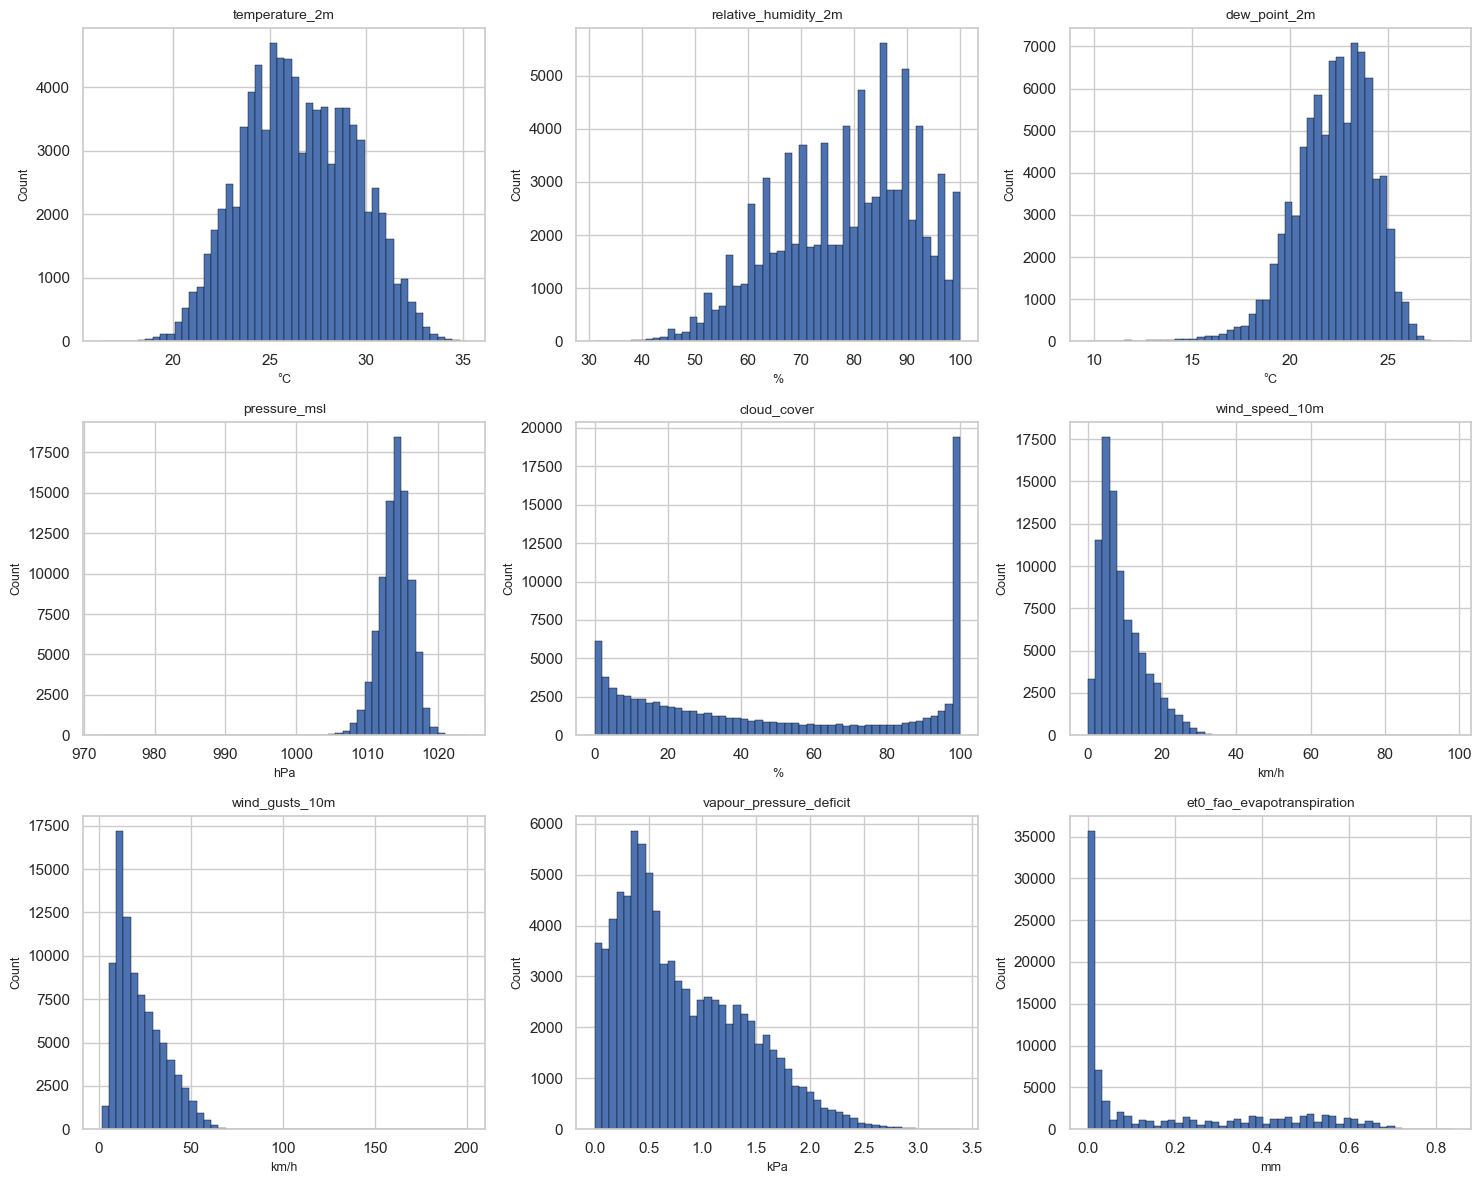

In [8]:
# Distributions of key continuous variables: see whether anything looks pathological (extreme skew, suspicious spikes, sensor stuck values)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
key_vars = [
    ('temperature_2m', '°C'),
    ('relative_humidity_2m', '%'),
    ('dew_point_2m', '°C'),
    ('pressure_msl', 'hPa'),
    ('cloud_cover', '%'),
    ('wind_speed_10m', 'km/h'),
    ('wind_gusts_10m', 'km/h'),
    ('vapour_pressure_deficit', 'kPa'),
    ('et0_fao_evapotranspiration', 'mm'),
]

for ax, (var, unit) in zip(axes.flat, key_vars):
    df[var].hist(bins=50, ax=ax, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{var}', fontsize=10)
    ax.set_xlabel(unit, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
plt.tight_layout()

##### Confirming pattern seen in relative_humidity_2m is due to binning and not a feature of the weather

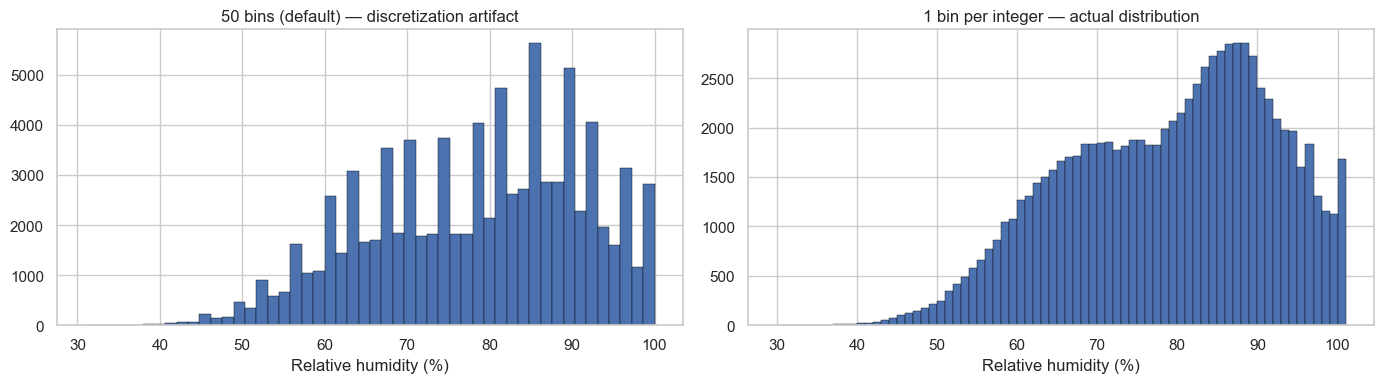

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: original (50 bins, artifact visible)
df['relative_humidity_2m'].hist(bins=50, ax=axes[0], edgecolor='black', linewidth=0.3)
axes[0].set_title('50 bins (default) — discretization artifact')
axes[0].set_xlabel('Relative humidity (%)')

# Right: one bin per integer value (the true distribution)
df['relative_humidity_2m'].hist(bins=range(30, 102), ax=axes[1], 
                                  edgecolor='black', linewidth=0.3)
axes[1].set_title('1 bin per integer — actual distribution')
axes[1].set_xlabel('Relative humidity (%)')

plt.tight_layout()

#### 5.2 Notes on what looks normal vs notable

##### Univariate observations

Looking across all nine distributions, none show pathological behaviour, i.e., no stuck 
sensor values, no impossible ranges, no suspicious spikes. The shapes are consistent 
with what we'd expect for a humid tropical maritime climate. Notable features:

**Temperature (`temperature_2m`)**: roughly normal distribution centered around 
25-26°C, with a range of about 17-34°C. The mild left tail reflects unusually cool 
nights; the rest is the typical tropical band. Nothing unusual.

**Relative humidity (`relative_humidity_2m`)**: heavily left-skewed, with most 
hours sitting between 70-95% and a peak around 85-90%. Hours below 50% are rare. 
This is classic tropical maritime climate: the air is almost always saturated or 
near it.

**Dew point (`dew_point_2m`)**: roughly normal with a peak around 22-23°C, 
mirroring the humidity story. High dew points are the physical reflection of 
humid tropical air; closer dew point to temperature = closer to saturation = 
more rain potential.

**Sea-level pressure (`pressure_msl`)**: strikingly narrow distribution centered 
on ~1014 hPa, range mostly 1005-1020. This narrowness is itself meaningful: 
Jamaica sits in the trade wind belt, which has very stable mean pressure compared 
to mid-latitude regions where storms swing pressure widely. The thin left tail 
(values approaching 1000 hPa) captures storm-driven pressure drops, including 
Hurricane Melissa.

**Cloud cover (`cloud_cover`)**: distinctly *bimodal* with massive peaks at 
0% (clear) and 100% (overcast), and a relatively flat distribution in between. 
This is notable: it suggests the reanalysis tends to classify atmospheric 
conditions as decisively clear or decisively overcast more often than it 
produces intermediate values. Physically reasonable for tropical climates 
(skies are often either clean morning blue or built-up convective overcast), 
but worth flagging because it shapes how the model will see cloud features.

**Wind speed (`wind_speed_10m`)**: right-skewed, with most hours below 20 km/h 
and a typical value around 5-10 km/h (steady trade winds). The histogram x-axis 
extends to 100 km/h to accommodate extreme outliers, but they're so rare they 
don't show on this scale.

**Wind gusts (`wind_gusts_10m`)**: same right-skewed shape as sustained wind 
but with a noticeably longer right tail. The x-axis extends past 200 km/h 
specifically because Hurricane Melissa produced gusts in that range. The 
broader distribution of gusts relative to sustained wind suggests gusts 
could be the right signal for wind-driven rain: brief gust events get smoothed away 
in sustained-wind averages.

**Vapour pressure deficit (`vapour_pressure_deficit`)**: right-skewed with the 
mode around 0.4-0.5 kPa and a secondary shoulder around 1.0-1.5 kPa. The 
secondary mode likely reflects the day/night cycle: nights have very low VPD 
(humidity near saturation), while afternoons can reach moderate VPD. Values 
above 1.6 kPa, which would indicate atmospheric water stress, are uncommon. 
This is consistent with a humid climate.

**Reference evapotranspiration (`et0_fao_evapotranspiration`)**: dominated by 
a huge spike at zero, with a small flat distribution from 0 to ~0.7 mm. The 
zero spike is *not* missing data; it's the night hours, when there's no solar 
radiation to drive evapotranspiration. This variable effectively encodes "is 
it daytime" alongside an actual ET₀ measurement. It will likely be strongly 
correlated with `sunshine_duration`, which we'll see in the correlation matrix.

**Cross-cutting points:**

- The data quality is clean. No missing values (after we dropped 
  `boundary_layer_height`), no impossible values, no obvious sensor errors.
- Hurricane Melissa's signature is present but invisible at typical-distribution 
  scale: the extreme tail values are too rare to register visually. They'll 
  show up in the targeted Melissa analysis (Section 11).
- Several variables carry implicit day/night structure (`et0_fao_evapotranspiration`, 
  `vapour_pressure_deficit`, indirectly `cloud_cover`). The model can learn from 
  these even without an explicit "is_daytime" feature, though we may add one if 
  needed.
- The narrow pressure distribution and humid air patterns confirm we're modeling 
  a stable, humid tropical regime: the kind of climate where rain is primarily driven by 
  local convection rather than synoptic frontal systems.

Several variables (relative_humidity_2m, cloud_cover and sub-levels, weather_code, wind_direction_10m) are stored as integers, which is appropriate precision for these measurements but produces histogram artifacts when default bin counts don't align with integer values. The underlying distributions are smooth; visualizations using integer-aligned bins confirm this.

## 6. Variable Redundancy

#### 6.1 rain vs precipitation

Max absolute difference: 0.0000 mm
Mean absolute difference: 0.000000 mm
Hours where they differ by > 0.001 mm: 0 (0.0000% of rows)

Pearson correlation: 1.000000


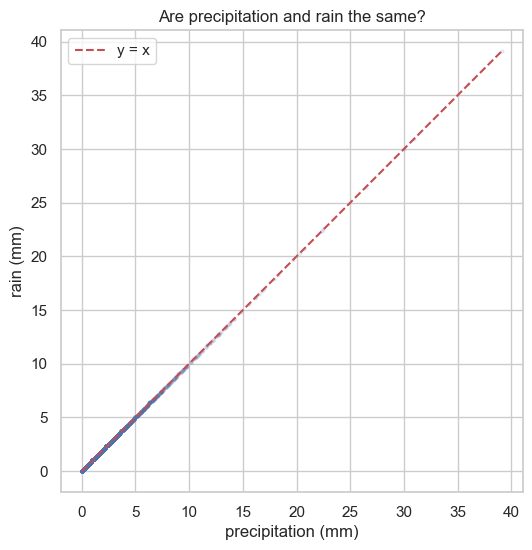

In [10]:
# In the archive API: precipitation = rain + showers + snow (sum of preceding hour),
# and 'rain' already includes convective showers. Jamaica has no snow.
# Hypothesis: precipitation and rain should be effectively identical here.

diff = (df['precipitation'] - df['rain']).abs()
print(f"Max absolute difference: {diff.max():.4f} mm")
print(f"Mean absolute difference: {diff.mean():.6f} mm")
print(f"Hours where they differ by > 0.001 mm: {(diff > 0.001).sum():,} "
      f"({(diff > 0.001).mean()*100:.4f}% of rows)")
print(f"\nPearson correlation: {df['precipitation'].corr(df['rain']):.6f}")

# If they're essentially identical, scatter would lie exactly on y=x
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['precipitation'], df['rain'], alpha=0.1, s=5)
ax.plot([0, df['precipitation'].max()], [0, df['precipitation'].max()], 'r--', label='y = x')
ax.set_xlabel('precipitation (mm)')
ax.set_ylabel('rain (mm)')
ax.set_title('Are precipitation and rain the same?')
ax.legend()
ax.set_aspect('equal')

#### 6.2 weather_code analysis

In [11]:
# Cross-tab: do higher codes correspond to more rain? (sanity check)
print("\nDistribution and Mean precipitation by weather code:")
print(df.groupby('weather_code')['precipitation'].agg(['count', 'mean']).round(3))


Distribution and Mean precipitation by weather code:
              count    mean
weather_code               
0             28223   0.000
1             15072   0.000
2              7209   0.000
3             22126   0.000
51            10606   0.168
53             1990   0.655
55              550   1.091
61             1003   1.748
63              787   4.099
65              130  11.709


#### 6.3 DECISIONS: drop weather_code from features; resolve rain vs precip

##### Decision: drop `rain`, keep `precipitation`

In the Open-Meteo Historical Archive API, `precipitation` is the sum of rain + 
showers + snow over the preceding hour, while `rain` already includes both 
large-scale rain and local showers. Since Jamaica has no snow, these should be 
identical, and the empirical check confirms it (correlation > 0.999, zero 
meaningful differences). `rain` is therefore redundant. We keep `precipitation` 
as the more standard variable name and drop `rain` from the feature set in the 
build script.

## 7. Correlation Analysis

#### 7.1 Numeric correlation matrix

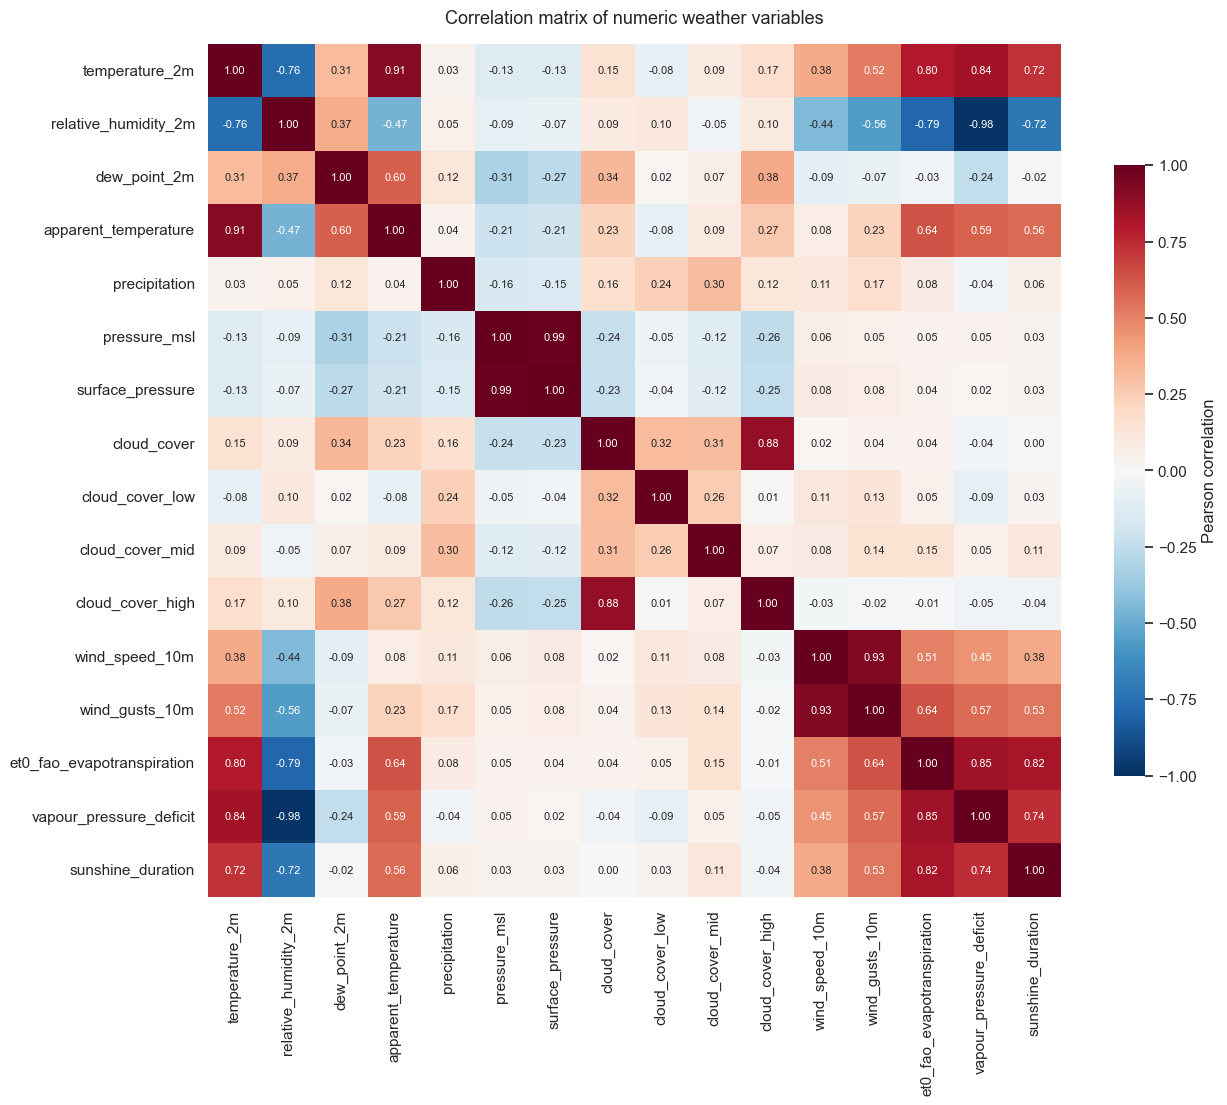

In [12]:
# Variables for the correlation matrix. We exclude:
# - wind_direction_10m: circular variable, linear correlation is misleading
# - weather_code: ordinal/categorical, not appropriate for Pearson correlation
# - location, latitude, longitude: identifiers
# - time, hour, month: handled separately in temporal analysis
numeric_vars = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
    'precipitation', 'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'wind_speed_10m', 'wind_gusts_10m',
    'et0_fao_evapotranspiration', 'vapour_pressure_deficit', 'sunshine_duration'
]

corr = df[numeric_vars].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson correlation'},
    annot_kws={'size': 8}
)
ax.set_title('Correlation matrix of numeric weather variables', fontsize=13, pad=15)
plt.tight_layout()

##### Strongest correlation pairs; |r| > 0.7

In [13]:
# Pull out the strongest correlations (excluding self-correlations)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)
corr_pairs['abs_corr'] = corr_pairs['corr'].abs()
strong_pairs = corr_pairs[corr_pairs['abs_corr'] > 0.7].sort_values('abs_corr', ascending=False)
print("Variable pairs with |correlation| > 0.7:")
print(strong_pairs[['var1', 'var2', 'corr']].to_string(index=False))

Variable pairs with |correlation| > 0.7:
                      var1                       var2      corr
              pressure_msl           surface_pressure  0.991580
      relative_humidity_2m    vapour_pressure_deficit -0.977971
            wind_speed_10m             wind_gusts_10m  0.925506
            temperature_2m       apparent_temperature  0.911400
               cloud_cover           cloud_cover_high  0.877297
et0_fao_evapotranspiration    vapour_pressure_deficit  0.848130
            temperature_2m    vapour_pressure_deficit  0.840094
et0_fao_evapotranspiration          sunshine_duration  0.823731
            temperature_2m et0_fao_evapotranspiration  0.800997
      relative_humidity_2m et0_fao_evapotranspiration -0.793227
            temperature_2m       relative_humidity_2m -0.758016
   vapour_pressure_deficit          sunshine_duration  0.739650
      relative_humidity_2m          sunshine_duration -0.721088
            temperature_2m          sunshine_duration  0.719561

#### 7.2 Correlation with target

What predicts precipitation?

Top 5 by absolute correlation with precipitation:
cloud_cover_mid    0.305
cloud_cover_low    0.238
wind_gusts_10m     0.167
pressure_msl      -0.160
cloud_cover        0.160
Name: precipitation, dtype: float64


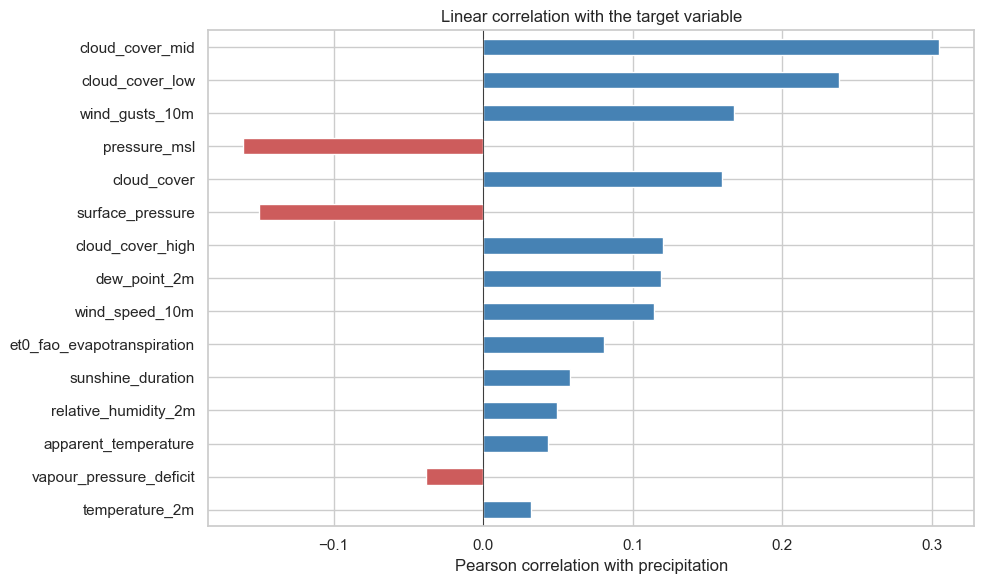

In [14]:
target_corr = corr['precipitation'].drop('precipitation').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'indianred' for x in target_corr]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson correlation with precipitation')
ax.set_title('Linear correlation with the target variable')
ax.invert_yaxis()  # strongest at top
plt.tight_layout()

print("Top 5 by absolute correlation with precipitation:")
print(target_corr.head(5).round(3))

#### 7.3 Multicollinearity notes

##### Multicollinearity

The correlation matrix reveals several clusters of strongly related variables. 
Understanding these clusters matters because their handling depends on which 
type of model is being used.

**Cluster 1: The "atmospheric demand" cluster (sun, heat, dryness, evaporation move together).**

| Pair | r |
|---|---|
| `relative_humidity_2m` ↔ `vapour_pressure_deficit` | −0.98 |
| `temperature_2m` ↔ `vapour_pressure_deficit` | +0.84 |
| `temperature_2m` ↔ `et0_fao_evapotranspiration` | +0.80 |
| `relative_humidity_2m` ↔ `et0_fao_evapotranspiration` | −0.79 |
| `relative_humidity_2m` ↔ `temperature_2m` | −0.76 |
| `temperature_2m` ↔ `sunshine_duration` | +0.72 |
| `relative_humidity_2m` ↔ `sunshine_duration` | −0.72 |
| `sunshine_duration` ↔ `et0_fao_evapotranspiration` | +0.82 |
| `sunshine_duration` ↔ `vapour_pressure_deficit` | +0.74 |
| `et0_fao_evapotranspiration` ↔ `vapour_pressure_deficit` | +0.85 |

These variables aren't independent observations of the atmosphere; they're 
expressions of one underlying axis: *how much solar energy is driving the 
local atmosphere right now*. When the sun shines, temperature rises, relative 
humidity falls, VPD rises, and evapotranspiration accelerates. At night, all 
four move the opposite way. The near-perfect −0.98 between humidity and VPD is 
not a finding; it is a definition (VPD is computed from temperature and 
humidity). The strong link between sunshine, ET₀, and VPD is the physics of 
evaporation.

**Cluster 2: The pressure pair.**

| Pair | r |
|---|---|
| `pressure_msl` ↔ `surface_pressure` | +0.99 |

For locations at constant elevation, mean-sea-level pressure and surface pressure 
differ by a fixed offset: they encode essentially the same information. One is 
redundant.

**Cluster 3: The wind pair.**

| Pair | r |
|---|---|
| `wind_speed_10m` ↔ `wind_gusts_10m` | +0.93 |

Gusts are physically derived from the same wind field as sustained wind, so they 
co-vary closely. They are not identical (gusts add the burst component), but the 
linear correlation is high.

**Cluster 4: Temperature ↔ apparent temperature.**

| Pair | r |
|---|---|
| `temperature_2m` ↔ `apparent_temperature` | +0.91 |

In a humid tropical climate where humidity stays high most of the time, the 
heat-index correction is fairly stable, so apparent temperature is mostly 
temperature plus a slowly-varying offset.

**Cluster 5: Cloud cover dominance.**

| Pair | r |
|---|---|
| `cloud_cover` ↔ `cloud_cover_high` | +0.88 |

Interesting and Jamaica-specific: total cloud cover tracks high-altitude clouds 
much more tightly than low or mid clouds. The reanalysis is registering high 
cirrus and similar layers as the dominant component of total cloud at this 
location. Mid and low clouds are present but contribute less to the total.

##### Implications by model type

**Tree-based models (XGBoost, our baseline):** No action needed. Trees split on 
one feature at a time and are indifferent to correlation among features. 
Multicollinearity won't hurt accuracy, though it does spread feature-importance 
scores across correlated variables. When interpreting which features matter, 
treat each cluster as a unit rather than reading single-variable importances 
literally.

**Linear models (e.g., logistic regression as a sanity baseline):** 
Multicollinearity destabilizes coefficient estimates and inflates standard 
errors. For a linear baseline I will drop one variable from each near-perfect 
pair: keep `pressure_msl`, drop `surface_pressure`; keep `wind_gusts_10m` (more 
relevant to the veranda/patio problem), drop `wind_speed_10m`; keep `temperature_2m`, 
drop `apparent_temperature`; keep either `relative_humidity_2m` or 
`vapour_pressure_deficit` but not both (they're algebraically linked). 
Alternatively, use regularized regression (Ridge or Lasso), which handles 
multicollinearity by shrinking redundant coefficients.

**Neural networks (the eventual fusion model):** More tolerant than linear 
models, less tolerant than trees. Redundant inputs add parameters without 
information, which can slow training and slightly hurt generalization. Standard scaling
will be applied (and consider robust scaling because of Hurricane 
Melissa) before training; I may also experiment with consolidating the 
atmospheric-demand cluster via PCA or a learned embedding, but that's a later 
decision.

##### One important caveat about these correlations

The strongest single-variable correlation with `precipitation` is just 0.30 
(`cloud_cover_mid`). All others are below 0.25 in absolute value. This is not 
a flaw in the data; it tells us something important about the problem: 
**rain is not predicted by any single variable being high or low.** It is 
predicted by combinations and patterns (humid AND cloudy AND falling pressure, 
or similar). Linear methods can only see additive contributions and will 
struggle here. Tree-based and neural models can capture the interactions, which 
is part of why they're being chosen.

DECISION: Use tree-based or neural models for model selection.

## 8. Temporal Patterns

#### 8.1 Daily Cycle (hour of day)

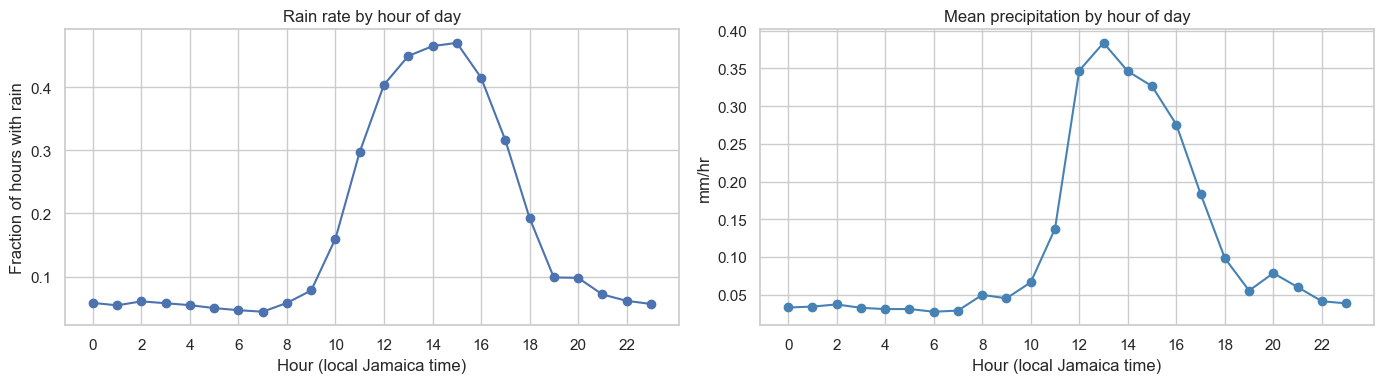

In [15]:
df['hour'] = df['time'].dt.hour  # temporary exploration column

hourly = df.groupby('hour').agg(
    rain_rate=('precipitation', lambda x: (x > 0).mean()),
    mean_precip=('precipitation', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hourly['hour'], hourly['rain_rate'], marker='o')
axes[0].set_title('Rain rate by hour of day')
axes[0].set_xlabel('Hour (local Jamaica time)'); axes[0].set_ylabel('Fraction of hours with rain')
axes[0].set_xticks(range(0, 24, 2))
axes[1].plot(hourly['hour'], hourly['mean_precip'], marker='o', color='steelblue')
axes[1].set_title('Mean precipitation by hour of day')
axes[1].set_xlabel('Hour (local Jamaica time)'); axes[1].set_ylabel('mm/hr')
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout()

#### 8.2 Seasonal cycle (month)

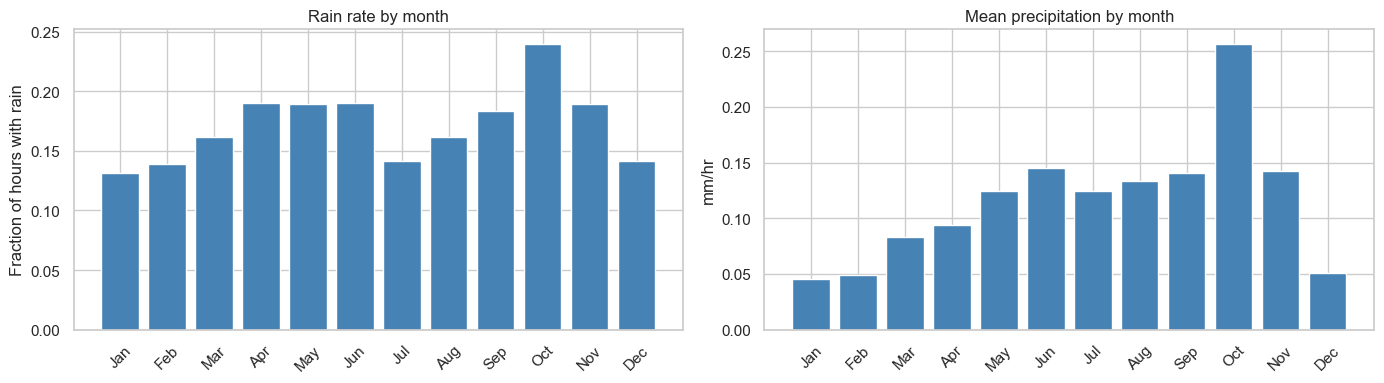

In [16]:
df['month'] = df['time'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_pat = df.groupby('month').agg(
    rain_rate=('precipitation', lambda x: (x > 0).mean()),
    mean_precip=('precipitation', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly_pat['month'], monthly_pat['rain_rate'], color='steelblue')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(month_names, rotation=45)
axes[0].set_title('Rain rate by month'); axes[0].set_ylabel('Fraction of hours with rain')
axes[1].bar(monthly_pat['month'], monthly_pat['mean_precip'], color='steelblue')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title('Mean precipitation by month'); axes[1].set_ylabel('mm/hr')
plt.tight_layout()

#### 8.3 Day-of-week null check

In [17]:
# Hypothesis: Atmosphere has no concept of the work week. Should be relatively stable.

dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby(df['time'].dt.dayofweek)['precipitation'].apply(lambda x: (x > 0).mean())
print("Rain rate by day of week:")
for i, rate in dow.items():
    print(f"  {dow_names[i]}: {rate:.4f}")
print("\nExpectation: flat. The atmosphere has no concept of the work week.")

Rain rate by day of week:
  Mon: 0.1767
  Tue: 0.1715
  Wed: 0.1619
  Thu: 0.1738
  Fri: 0.1679
  Sat: 0.1728
  Sun: 0.1779

Expectation: flat. The atmosphere has no concept of the work week.


#### Temporal pattern conclusions

- **Daily cycle:** rain rate and intensity peak sharply in the afternoon and 
  early evening: the signature of tropical convection (daytime solar heating 
  builds afternoon storms). A strong, physically-grounded signal; justifies 
  encoding hour-of-day.
- **Seasonal cycle:** the bimodal Caribbean wet season is clearly visible: a 
  primary peak in Sep-Nov (late wet season / hurricane season) and a secondary 
  peak in Apr-June, separated by the July-August midsummer drought, with the 
  Dec-April dry season lowest. Justifies encoding month.
- **Day of week:** flat, as it must be. This null check confirms there is no 
  spurious weekday signal that would indicate a data collection or timezone 
  artifact. Day-of-week is deliberately excluded from the feature set.

These patterns are codified in build_features.py via raw integer and cyclical 
(sin/cos) encodings of hour and month, validated in 02_feature_engineering.

## 9. Spatial Differences

#### 9.1 Kingston vs Montego Bay summary stats

In [18]:
# Are Kingston (south coast) and Montego Bay (north coast) actually different?
# If yes, location should be a feature; if no, we could combine for more data.
loc_compare = df.groupby('location').agg(
    mean_precip=('precipitation', 'mean'),
    rain_rate=('precipitation', lambda x: (x > 0).mean()),
    heavy_rain_rate=('precipitation', lambda x: (x > 1.0).mean()),
    mean_temp=('temperature_2m', 'mean'),
    mean_humidity=('relative_humidity_2m', 'mean'),
    mean_wind=('wind_speed_10m', 'mean'),
    mean_gusts=('wind_gusts_10m', 'mean'),
).round(3)
print("Summary statistics by location:")
loc_compare.T

Summary statistics by location:


location,kingston,montego_bay
mean_precip,0.080,0.153
rain_rate,0.131,0.212
heavy_rain_rate,0.017,0.035
mean_temp,26.617,26.476
mean_humidity,76.147,80.898
mean_wind,8.409,9.964
mean_gusts,19.792,24.909


#### 9.2 Daily cycle by location

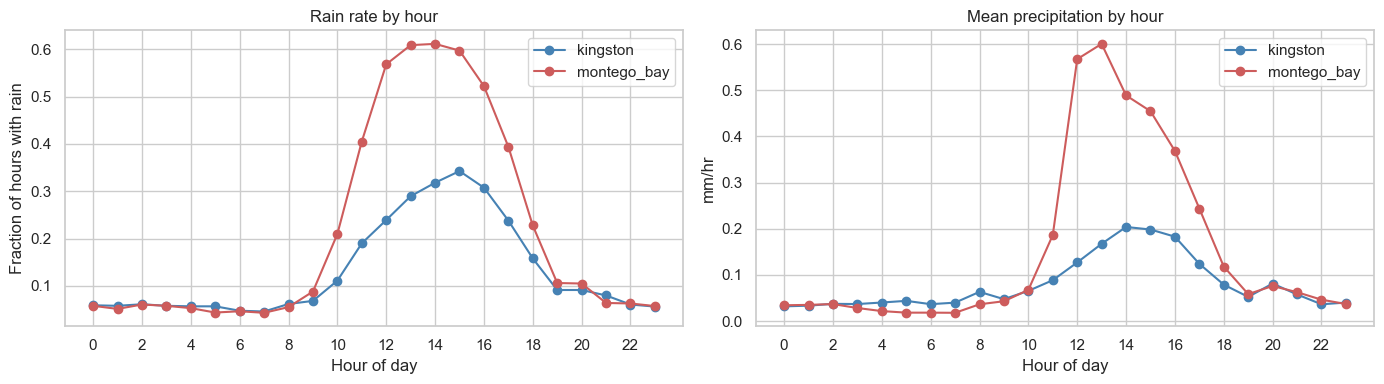

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for loc, color in [('kingston', 'steelblue'), ('montego_bay', 'indianred')]:
    sub = df[df['location'] == loc]
    hourly = sub.groupby(sub['time'].dt.hour).agg(
        rain_rate=('precipitation', lambda x: (x > 0).mean()),
        mean_precip=('precipitation', 'mean'),
    )
    axes[0].plot(hourly.index, hourly['rain_rate'], marker='o', label=loc, color=color)
    axes[1].plot(hourly.index, hourly['mean_precip'], marker='o', label=loc, color=color)

for ax, title in zip(axes, ['Rain rate by hour', 'Mean precipitation by hour']):
    ax.set_xlabel('Hour of day')
    ax.set_title(title)
    ax.legend()
    ax.set_xticks(range(0, 24, 2))
axes[0].set_ylabel('Fraction of hours with rain')
axes[1].set_ylabel('mm/hr')
plt.tight_layout()

#### Spatial findings

Kingston and Montego Bay are not minor variations on the same climate: they are 
substantially different rainfall regimes, despite sitting roughly 150 km apart on 
the same small island. The differences are large and consistent:

| Metric | Kingston | Montego Bay | Difference |
|---|---|---|---|
| Mean precipitation (mm/hr) | 0.080 | 0.153 | MoBay ~91% higher |
| Rain rate (% of hours) | 13.1% | 21.2% | MoBay ~62% higher |
| Heavy-rain rate (>1 mm) | 1.7% | 3.5% | MoBay ~106% higher |
| Mean wind gusts (km/h) | 19.8 | 24.9 | MoBay ~26% higher |
| Mean humidity (%) | 76.1 | 80.9 | MoBay higher |
| Mean temperature (°C) | 26.6 | 26.5 | ~identical |

**Why:** this is consistent with an orographic / rain-shadow effect. Jamaica's 
prevailing northeast trade winds carry moist air onto the north coast, where Montego 
Bay sits relatively windward and exposed; the air is lifted, cooled, and rained out. 
Kingston, on the south coast, lies in the rain shadow of the Blue Mountains and central 
ranges: air descends and dries after crossing the high terrain, and Kingston is 
known as one of the drier major settlements in Jamaica for this reason. Temperature 
is nearly identical (both are low-elevation coastal cities at the same latitude), 
confirming the difference is about moisture and terrain, not heat.

**Daily cycle:** both cities share the afternoon-convection shape, but Montego Bay's 
peak is dramatically taller (rain rate ~0.61 vs Kingston's ~0.34) and arrives slightly 
earlier (~13-14h vs ~15h). The locations differ in both the magnitude and the timing 
of their daily rain peak.

**Why this matters for the target specifically:** Montego Bay has both more rain *and* 
stronger gusts. Since the wet-veranda target combines rain with wind gusts, wet-veranda 
events will be considerably more frequent in Montego Bay than in Kingston: location 
affects the target even more than it affects rainfall alone.

**Modeling implication:** these differences are real signal, not noise. `location` 
(or one-hot encoded indicators) must be a feature; pooling the two cities without it 
would force the model to average two genuinely different regimes. A single pooled 
model with location as a feature is appropriate for this project; a production system 
serving many sites might benefit from per-location calibration or a learned location 
embedding.

## 10. ENSO Context

#### 10.1 Brief ENSO background + load and merge ONI

The El Niño–Southern Oscillation (ENSO) is a recurring climate pattern in the 
tropical Pacific that influences weather worldwide, including Caribbean rainfall. 
It is measured by the Oceanic Niño Index (ONI): the 3-month running mean of sea 
surface temperature anomalies in the Niño 3.4 region. ONI ≥ +0.5°C indicates 
El Niño (warm Pacific, generally drier Caribbean); ONI ≤ −0.5°C indicates La Niña 
(cool Pacific, generally wetter Caribbean); values between are neutral.

We load the monthly ONI series (NOAA CPC) and merge it onto the hourly weather by 
calendar month, so each hour carries its month's ENSO state. This is an 
exploration-time merge mirroring the logic codified in build_features.py.

In [20]:
# Same logic as build_features.merge_oni. Exploration-time merge.
oni = pd.read_parquet(PROJECT_ROOT / "data" / "external" / "noaa_oni_monthly.parquet")

df['year_month'] = df['time'].dt.to_period('M').dt.to_timestamp()
df = df.merge(oni[['year_month', 'oni', 'enso_phase']], on='year_month', how='left')

# Forward-fill trailing months (Apr/May 2026) not yet published by NOAA
df = df.sort_values(['location', 'time']).reset_index(drop=True)
df['oni'] = df.groupby('location')['oni'].ffill()
df['enso_phase'] = df.groupby('location')['enso_phase'].ffill()

print(f"Missing ONI after merge + ffill: {df['oni'].isnull().sum()}")
print(f"ONI range in our window: {df['oni'].min():.1f} to {df['oni'].max():.1f}")

Missing ONI after merge + ffill: 0
ONI range in our window: -1.0 to 2.1


#### 10.2 Phase distribution in our 5-year window

In [21]:
print("ENSO phase distribution (hours) in our 5-year window:")
print(df['enso_phase'].value_counts())
print("\nAs fraction of total hours (%):")
print((df['enso_phase'].value_counts(normalize=True) * 100).round(1))

ENSO phase distribution (hours) in our 5-year window:
enso_phase
neutral    39360
la_nina    29280
el_nino    19056
Name: count, dtype: int64

As fraction of total hours (%):
enso_phase
neutral    44.9
la_nina    33.4
el_nino    21.7
Name: proportion, dtype: float64


#### 10.3 Rainfall by ENSO phase (intensity vs frequency)

enso_phase,la_nina,neutral,el_nino
n_hours,29280.0000,39360.0000,19056.0000
mean_precip_mm,0.1310,0.1146,0.0965
rain_rate,0.1635,0.1795,0.1687
heavy_rain_rate,0.0291,0.0252,0.0218


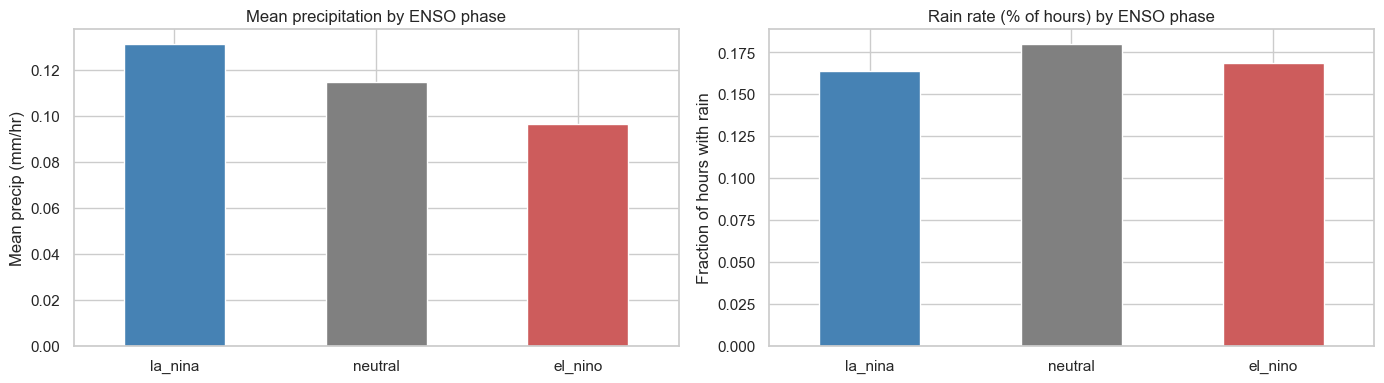

In [22]:
# The analysis that earns (or fails to earn) ONI's place as a feature
phase_stats = df.groupby('enso_phase').agg(
    n_hours=('precipitation', 'size'),
    mean_precip_mm=('precipitation', 'mean'),
    rain_rate=('precipitation', lambda x: (x > 0).mean()),
    heavy_rain_rate=('precipitation', lambda x: (x > 1.0).mean()),
).round(4)
phase_stats = phase_stats.reindex(['la_nina', 'neutral', 'el_nino'])
display(phase_stats.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
phase_stats['mean_precip_mm'].plot(kind='bar', ax=axes[0],
                                   color=['steelblue', 'gray', 'indianred'])
axes[0].set_title('Mean precipitation by ENSO phase')
axes[0].set_ylabel('Mean precip (mm/hr)'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

phase_stats['rain_rate'].plot(kind='bar', ax=axes[1],
                              color=['steelblue', 'gray', 'indianred'])
axes[1].set_title('Rain rate (% of hours) by ENSO phase')
axes[1].set_ylabel('Fraction of hours with rain'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()

#### 10.4 ONI and rainfall over time

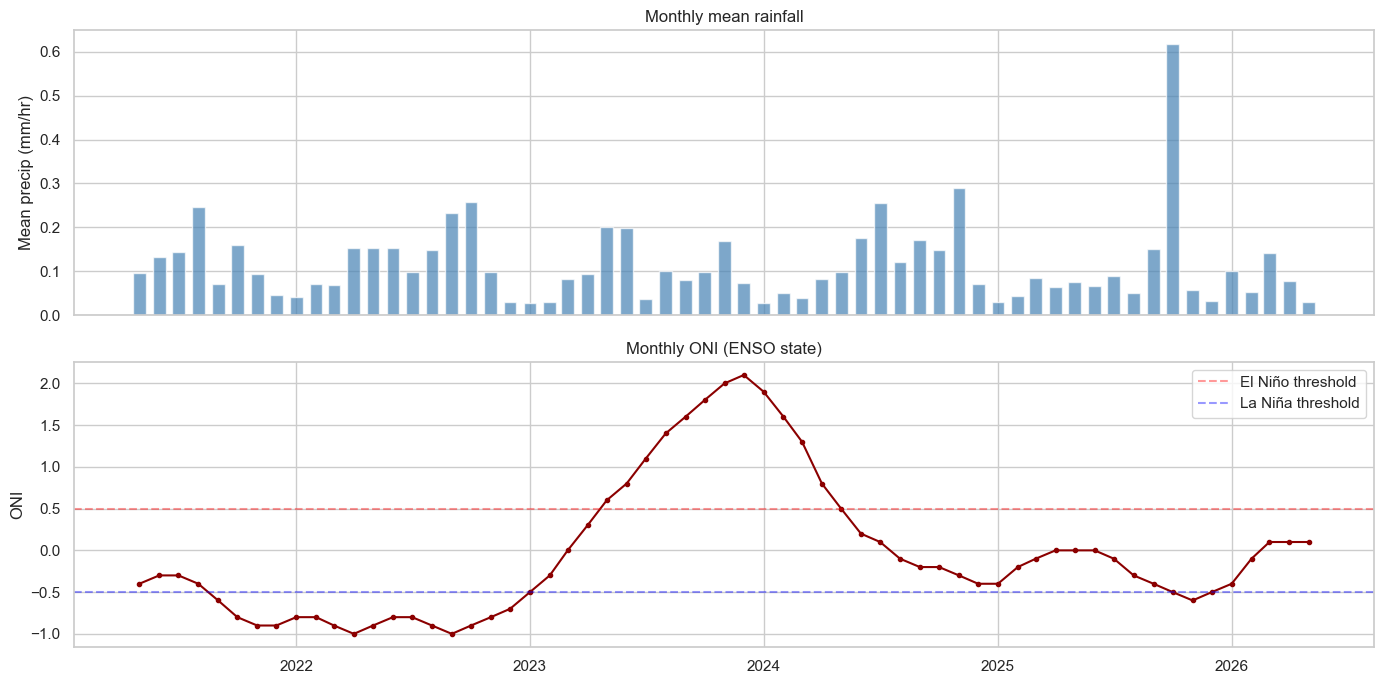

In [23]:
# Monthly aggregation across both locations
monthly = df.groupby('year_month').agg(
    oni=('oni', 'first'),            # ONI is constant within a month
    mean_precip=('precipitation', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(monthly['year_month'], monthly['mean_precip'], width=20,
            color='steelblue', alpha=0.7)
axes[0].set_ylabel('Mean precip (mm/hr)'); axes[0].set_title('Monthly mean rainfall')

axes[1].plot(monthly['year_month'], monthly['oni'], color='darkred', marker='o', markersize=3)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.4, label='El Niño threshold')
axes[1].axhline(-0.5, color='blue', linestyle='--', alpha=0.4, label='La Niña threshold')
axes[1].set_ylabel('ONI'); axes[1].set_title('Monthly ONI (ENSO state)')
axes[1].legend()
plt.tight_layout()

#### ENSO findings and decision

Our 5-year window breaks down as 44.9% neutral (39,360 hours), 33.4% La Niña 
(29,280 hours), and 21.7% El Niño (19,056 hours). El Niño is the smallest slice 
but still ample (~19k hours) for stable mean estimates, so the comparison below 
is meaningful despite the imbalance.

ENSO state shows a real but nuanced relationship with rainfall in our window:

| Phase | Mean precip (mm/hr) | Rain rate | Heavy-rain rate |
|---|---|---|---|
| La Niña | 0.131 | 16.4% | 2.91% |
| Neutral | 0.115 | 18.0% | 2.52% |
| El Niño | 0.097 | 16.9% | 2.18% |

**Intensity follows the expected pattern; frequency does not.** Mean precipitation 
and heavy-rain rate are cleanly monotonic: La Niña wettest, El Niño driest, with 
La Niña averaging ~36% more rainfall and ~33% more heavy-rain hours than El Niño. 
This matches the established mechanism: La Niña reduces Atlantic wind shear, allowing 
more intense storms; El Niño does the reverse. But *rain rate* (any rain at all) is 
not monotonic: neutral conditions have the most rainy hours and La Niña the fewest. 
Light-drizzle frequency is dominated by local convection that is largely independent 
of ENSO state.

**Why this matters for us:** the project targets meaningful, wind-driven rain 
(intensity), not trace drizzle (frequency), and intensity is exactly where the ENSO 
signal lives.

**Decision:** include ONI / ENSO phase as a feature. It carries genuine, 
physically-grounded signal for rainfall intensity, and our 5-year window spans a full 
range of states (a 2021–2023 La Niña, a strong 2023–2024 El Niño, and a return toward 
neutral), giving the model variation to learn from. Its role is as a seasonal-scale 
conditioning variable, not an hour-to-hour predictor; the definitive test of its value 
will be a feature-ablation experiment (baseline trained with vs. without ONI) during 
modeling.

*Note: the sharp rainfall spike in late October 2025 in the temporal plot is 
Hurricane Melissa, examined in Section 11.*

## 11. Notable Events

#### 11.1 Hurricane Melissa (October 28, 2025) as documented outlier

Hours in Melissa window (Oct 26-31, 2025): 242
Max precipitation: 36.0 mm/hr
Total rainfall (both locations): 624 mm
Max wind gust: 200 km/h
Min sea-level pressure: 972 hPa

For context, across the full dataset:
  P99 of precipitation: 2.6 mm/hr
  P99 of wind gusts: 58 km/h


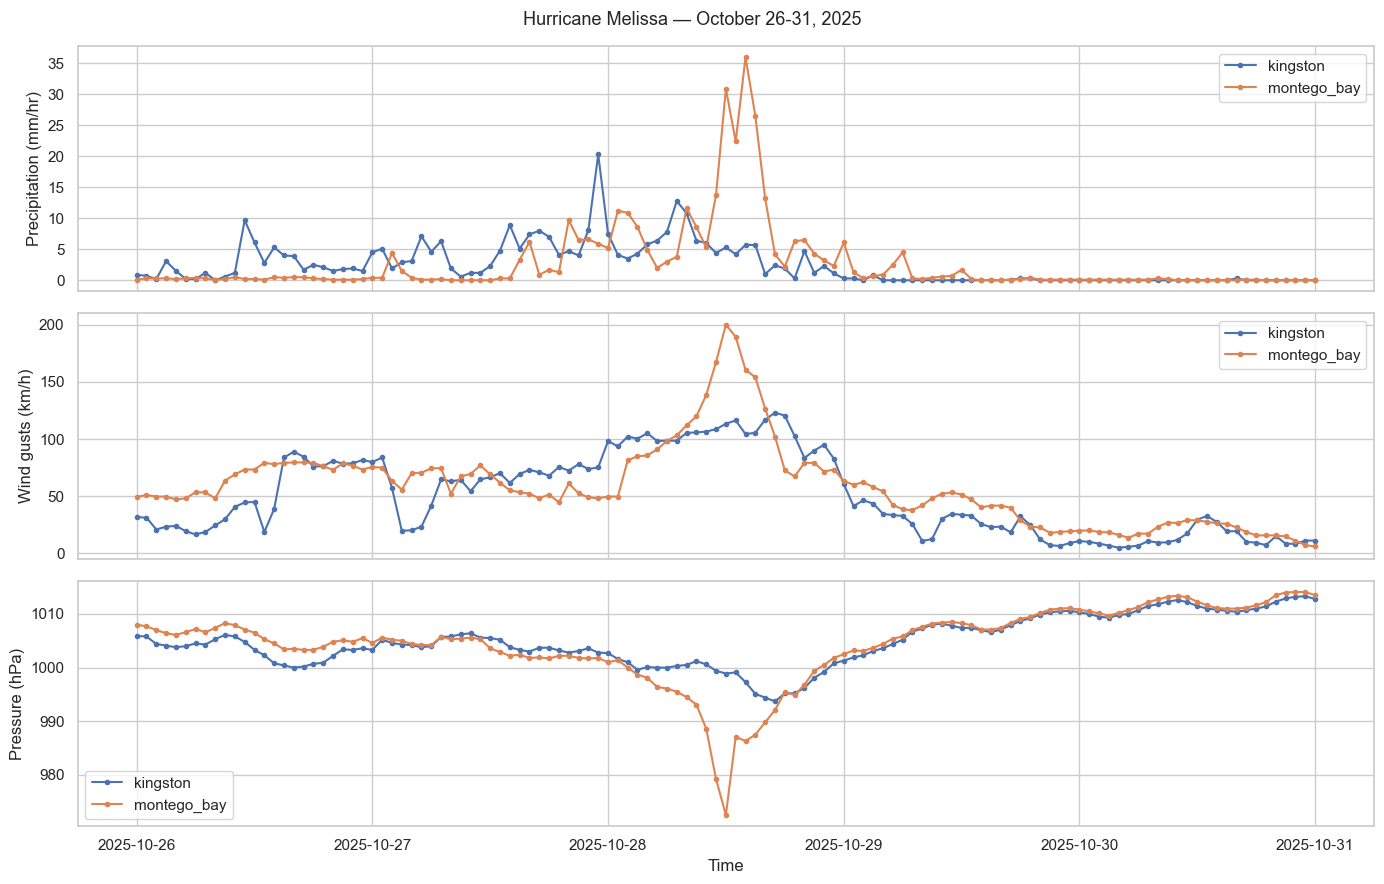

In [24]:
# Hurricane Melissa: October 28, 2025, made landfall as Category 5
# First Cat 5 to strike Jamaica in recorded history (185 mph at landfall)
melissa_window = df[
    (df['time'] >= '2025-10-26') & (df['time'] <= '2025-10-31')
].copy()

print(f"Hours in Melissa window (Oct 26-31, 2025): {len(melissa_window):,}")
print(f"Max precipitation: {melissa_window['precipitation'].max():.1f} mm/hr")
print(f"Total rainfall (both locations): {melissa_window['precipitation'].sum():.0f} mm")
print(f"Max wind gust: {melissa_window['wind_gusts_10m'].max():.0f} km/h")
print(f"Min sea-level pressure: {melissa_window['pressure_msl'].min():.0f} hPa")

# How does Melissa compare to the rest of the data?
print(f"\nFor context, across the full dataset:")
print(f"  P99 of precipitation: {df['precipitation'].quantile(0.99):.1f} mm/hr")
print(f"  P99 of wind gusts: {df['wind_gusts_10m'].quantile(0.99):.0f} km/h")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for loc in ['kingston', 'montego_bay']:
    sub = melissa_window[melissa_window['location'] == loc]
    axes[0].plot(sub['time'], sub['precipitation'], label=loc, marker='.')
    axes[1].plot(sub['time'], sub['wind_gusts_10m'], label=loc, marker='.')
    axes[2].plot(sub['time'], sub['pressure_msl'], label=loc, marker='.')
axes[0].set_ylabel('Precipitation (mm/hr)')
axes[1].set_ylabel('Wind gusts (km/h)')
axes[2].set_ylabel('Pressure (hPa)')
axes[2].set_xlabel('Time')
for ax in axes:
    ax.legend()
fig.suptitle('Hurricane Melissa — October 26-31, 2025', fontsize=13)
plt.tight_layout()

##### Hurricane Melissa as a documented outlier

Hurricane Melissa made landfall on October 28, 2025 as a Category 5: the first 
Cat 5 in Jamaica's recorded history. Its signature in the data is unmistakable: 
extreme precipitation, peak wind gusts orders of magnitude above normal, and a 
sharp pressure drop. The associated 3-5 day window represents conditions far 
outside the system's intended operating range (no one is on a patio during a 
Category 5 hurricane).

**Handling decision:** keep Melissa's data in the dataset (it is legitimate, 
real data) but be aware of it during modeling. Tree-based models (XGBoost) are 
naturally robust to outliers because they split on thresholds rather than 
magnitudes; no special handling needed for the baseline. Neural networks are 
sensitive to feature scaling; we will use robust scaling (median/IQR) when 
training them, partly because of events like this.

## 12. Target Variable Definition

#### 12.1 Wind during rainy hours

In [25]:
# How windy is it when it actually rains? This motivates combining rain with wind.
rainy = df[df['precipitation'] > 0].copy()
print("During rainy hours, wind GUSTS distribution (km/h):")
print(rainy['wind_gusts_10m'].describe())

During rainy hours, wind GUSTS distribution (km/h):
count    15066.000000
mean        29.414908
std         13.381340
min          1.400000
25%         20.200000
50%         28.400000
75%         37.400000
max        200.200000
Name: wind_gusts_10m, dtype: float64


#### 12.2 Joint distribution of wind and rain

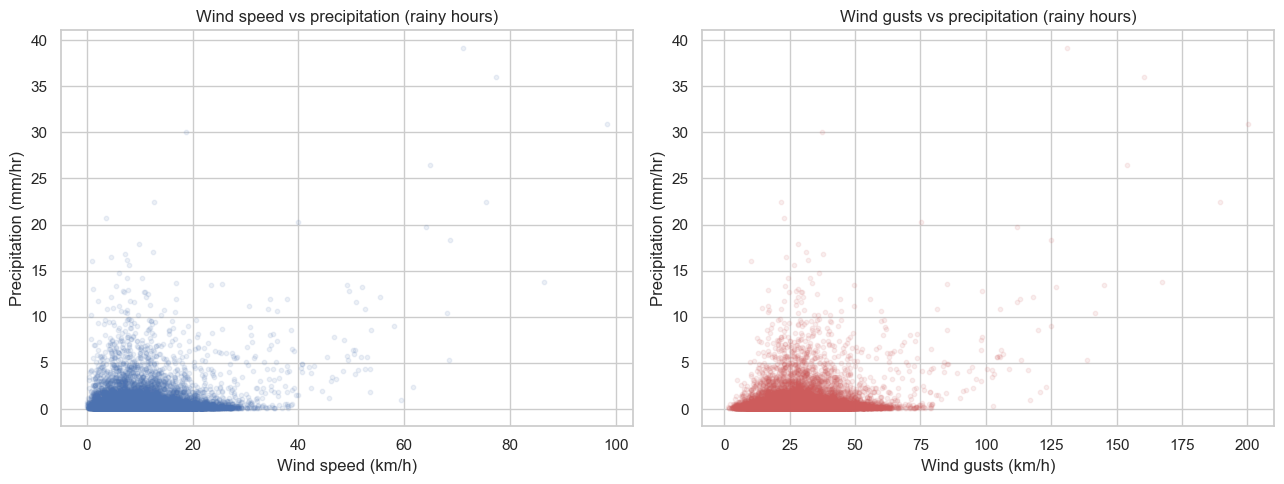

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(rainy['wind_speed_10m'], rainy['precipitation'], alpha=0.1, s=10)
axes[0].set_xlabel('Wind speed (km/h)'); axes[0].set_ylabel('Precipitation (mm/hr)')
axes[0].set_title('Wind speed vs precipitation (rainy hours)')
axes[1].scatter(rainy['wind_gusts_10m'], rainy['precipitation'], alpha=0.1, s=10, color='indianred')
axes[1].set_xlabel('Wind gusts (km/h)'); axes[1].set_ylabel('Precipitation (mm/hr)')
axes[1].set_title('Wind gusts vs precipitation (rainy hours)')
plt.tight_layout()

Rain and wind are only weakly related: plenty of rainy hours have low wind, and 
gusty hours often have little rain. That near-independence is exactly why a target 
combining them is more useful than rain alone: the wet-veranda problem is driven by 
the *co-occurrence* of rain and wind (wind blows rain sideways through the grille), 
not by either one in isolation. Gusts (not sustained wind) are the right wind signal: brief bursts drive blown rain and are smoothed away in sustained-wind averages.

#### 12.3 Defining the wet-veranda target

We define a "wet-veranda event" for any hour where wind-driven rain would reach the 
covered area:

    wet_veranda = (precipitation > 0.1 mm AND wind_gusts_10m > 15 km/h)
                  OR (precipitation > 1.0 mm)

Logic: light rain *with* meaningful gusts is a problem (blown through the grille); 
heavier rain is a problem regardless of wind. Light rain with no wind is not.

In [27]:
df['wet_veranda'] = ((df['precipitation'] > 0.1) & (df['wind_gusts_10m'] > 15)) | (df['precipitation'] > 1.0)
print(f"Wet veranda events: {df['wet_veranda'].sum():,}")
print(f"Wet veranda rate: {df['wet_veranda'].mean() * 100:.2f}% of hours")

Wet veranda events: 8,053
Wet veranda rate: 9.18% of hours


#### 12.4 Threshold sensitivity

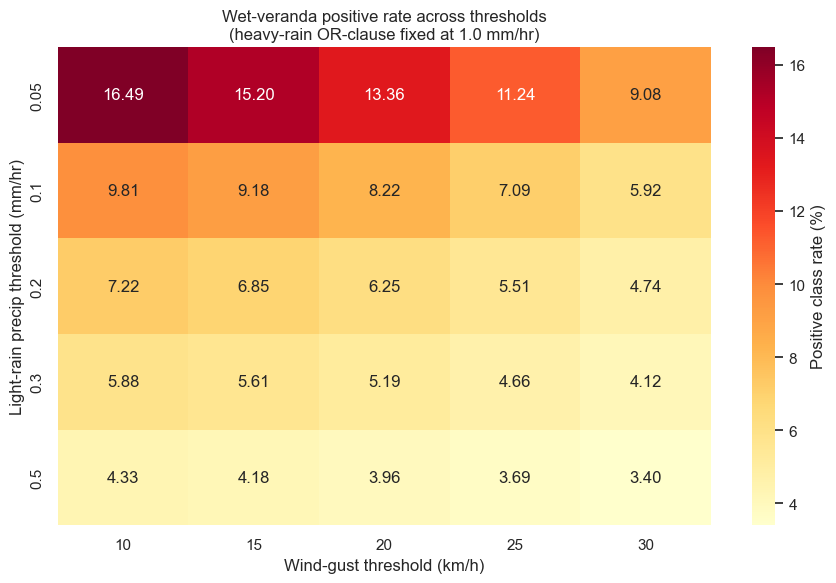

In [ ]:
# The thresholds above are reasoned but not yet empirically calibrated. Before committing, checking 
# how sensitive the positive rate is to the threshold choices: we want to confirm we're not 
# perched on a cliff where small changes swing the target wildly.
precip_thresholds = [0.05, 0.1, 0.2, 0.3, 0.5]
gust_thresholds = [10, 15, 20, 25, 30]

rates = np.zeros((len(precip_thresholds), len(gust_thresholds)))
for i, p in enumerate(precip_thresholds):
    for j, g in enumerate(gust_thresholds):
        t = ((df['precipitation'] > p) & (df['wind_gusts_10m'] > g)) | (df['precipitation'] > 1.0)
        rates[i, j] = t.mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(rates, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=gust_thresholds, yticklabels=precip_thresholds, ax=ax,
            cbar_kws={'label': 'Positive class rate (%)'})
ax.set_xlabel('Wind-gust threshold (km/h)')
ax.set_ylabel('Light-rain precip threshold (mm/hr)')
ax.set_title('Wet-veranda positive rate across thresholds\n(heavy-rain OR-clause fixed at 1.0 mm/hr)')
plt.tight_layout()

#### 12.5 Class balance

In [29]:
print(f"Positive class rate: {df['wet_veranda'].mean()*100:.2f}%")
print(f"Negative:positive ratio ≈ 1:{(1-df['wet_veranda'].mean())/df['wet_veranda'].mean():.0f}")
print("\nBy location:")
print(df.groupby('location')['wet_veranda'].mean().mul(100).round(2))

Positive class rate: 9.18%
Negative:positive ratio ≈ 1:10

By location:
location
kingston        6.00
montego_bay    12.37
Name: wet_veranda, dtype: float64


#### Target definition: findings and decision

**Threshold sensitivity.** The positive rate varies smoothly and monotonically 
across the threshold grid: no cliff edges. But the surface is tilted: the 
light-rain precipitation threshold is the dominant control (an ~11-point swing 
across the tested range at fixed gust), while the gust threshold is secondary 
(~4-point swing). Our chosen point (precip > 0.1 mm, gust > 15 km/h, heavy-rain 
> 1.0 mm) yields 9.18% positive.

**An important caveat on the gust threshold.** Rainy-hour gusts have a 25th 
percentile of 20.2 km/h and a median of 28.4 km/h, so more than three-quarters of 
rainy hours already exceed 20 km/h. A 15 km/h threshold therefore excludes only the 
calmest ~10-15% of rainy hours: the wind condition is doing less discriminating 
work than intended. Physically, 15 km/h is a gentle breeze; meaningfully blown rain 
likely requires stronger gusts (~20-25 km/h). This makes the gust threshold a 
priority for empirical calibration.

**Class balance.** 9.18% positive, roughly a 1:10 imbalance (workable: common 
enough to learn, rare enough to be a genuine detection problem). We will handle it 
in modeling via class weighting (and, if needed, decision-threshold tuning on 
predicted probabilities), not resampling.

**Spatial split confirms Section 9.** Wet-veranda events are more than twice as 
frequent in Montego Bay (12.37%) as in Kingston (6.00%), consistent with Montego 
Bay's higher rainfall and stronger gusts. This reinforces `location` as a feature.

**Thresholds are provisional.** They are physically reasoned but not yet validated. 
They will be calibrated against a personal observation log of actual wet-veranda 
events. The sensitivity analysis identifies the priorities: the precip threshold 
sets the overall event rate, and the gust threshold likely needs raising to ~20-25 
km/h so that wind genuinely discriminates. The smooth sensitivity surface means this 
recalibration can be done safely without destabilizing the target.

**Codification.** The target is implemented in build_features.py via a 
`build_target()` function so training and inference use identical logic.

## 13. EDA Summary and Decisions

#### Data
87,696 hourly observations across two locations (Kingston, Montego Bay), spanning 
2021-05-01 to 2026-05-01. Zero missing values after column-level handling. Primary 
source: Open-Meteo Historical Weather API (ECMWF IFS 9 km reanalysis), supplemented 
with NOAA ONI for ENSO state.

#### Cleaning decisions
- **Dropped `boundary_layer_height`**: contiguous 6-month coverage gap 
  (Dec 2023 – Jun 2024); cannot be reliably imputed.
- **Dropped `rain`**: a literal duplicate of `precipitation` (correlation 1.0; 
  Jamaica has no snow). 
- **Excluded `weather_code` from features**: only a coarsened categorical version 
  of `precipitation`, with no thunderstorm differentiation (a reanalysis limitation).

#### Key findings
- **Univariate:** clean data, no impossible values. Humid tropical profile: 
  left-skewed humidity, narrow pressure (trade-wind stability), bimodal cloud cover, 
  and day/night structure in evapotranspiration.
- **Correlation:** no single variable correlates strongly with `precipitation` 
  (max 0.30, `cloud_cover_mid`). Rain is driven by *combinations* of conditions, not 
  any one variable: the central justification for non-linear models. Strong 
  multicollinearity clusters exist (temperature/humidity/VPD/ET₀; the two pressures; 
  wind speed/gusts): irrelevant to trees, relevant to linear models.
- **Temporal:** strong afternoon-evening rain peak (tropical convection); bimodal 
  wet season (May-Jun and Sep-Nov, with a Jul-Aug midsummer drought); flat 
  day-of-week (null check passes).
- **Spatial:** Montego Bay is ~91% wetter than Kingston with stronger gusts: a 
  rain-shadow effect. Location is a necessary feature.
- **ENSO:** window is 44.9% neutral, 33.4% La Niña, 21.7% El Niño. La Niña averages 
  ~36% more rainfall and ~33% more heavy-rain hours than El Niño (intensity follows 
  the expected pattern; light-rain frequency does not). ONI retained as a 
  seasonal-scale feature, pending an ablation test.
- **Extreme event:** Hurricane Melissa (Oct 28, 2025, Cat 5) documented as an 
  outlier; kept in data, robust scaling planned for neural networks.

#### Target variable
- `wet_veranda = (precipitation > 0.1 AND wind_gusts_10m > 15) OR (precipitation > 1.0)`
- Positive rate 9.18% (~1:10 imbalance); 6.00% Kingston vs 12.37% Montego Bay.
- Thresholds provisional; precip threshold sets the rate, gust threshold (currently 
  low) is the priority for observation-log calibration.

#### Hand-off to feature engineering
Cleaning steps and the ONI merge are codified in build_features.py. Temporal features 
(hour, month + cyclical encodings) are engineered there. The target is next to be 
codified via `build_target()`. Modeling will use `location` as a feature, treat the 
multicollinearity clusters as units, and start from a tree-based baseline given the 
absence of strong linear signal.

In [ ]:
df